# 🖼️ Klasyfikacja obrazów CIFAR-10 przy użyciu sieci MLP
**Zadanie 3 | Grupa 1 (Sieć MLP)** 🧠

Celem tego notatnika jest implementacja od podstaw wielowarstwowego perceptronu (MLP) do klasyfikacji obrazów ze zbioru CIFAR-10. Proces obejmuje analizę danych 📊, budowę architektury sieci 🏗️, przeprowadzenie serii eksperymentów z hiperparametrami 🧪 oraz finalną ewaluację najlepszego modelu 🏆.

## 1. Import bibliotek i konfiguracja środowiska 🛠️

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Ustawienie ziarna losowości dla powtarzalności wyników 🌱
torch.manual_seed(42)

# Konfiguracja urządzenia (GPU jeśli dostępne, w przeciwnym razie CPU) 💻
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Obliczenia będą wykonywane na: {device}")

🚀 Obliczenia będą wykonywane na: cuda


## 2. Przygotowanie i analiza zbioru danych (EDA) 📦

Zbiór CIFAR-10 składa się z 60 000 kolorowych obrazów o wymiarach 32x32 pikseli, podzielonych na 10 klas.
Aby przygotować dane dla sieci neuronowej, stosujemy dwie kluczowe transformacje:
1. **ToTensor()** 🔄: Konwertuje obrazy na tensory PyTorch oraz skaluje wartości pikseli z zakresu [0, 255] do [0.0, 1.0].
2. **Normalize()** ⚖️: Normalizuje dane, przesuwając średnią do 0 i odchylenie standardowe do 1, co znacząco stabilizuje proces uczenia.


In [2]:
# Definiujemy transformacje
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Pobieranie zbioru treningowego i testowego 📥
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Nazwy klas w zbiorze CIFAR-10 🏷️
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Podstawowe statystyki 📈
print(f"Liczba obrazów treningowych: {len(train_dataset)}")
print(f"Liczba obrazów testowych: {len(test_dataset)}")
print(f"Kształt pojedynczego obrazu: {train_dataset[0][0].shape} (Kanały, Wysokość, Szerokość)")

# Sprawdzenie zakresu wartości pikseli (po normalizacji)
sample_image_tensor = train_dataset[0][0]
print(f"Zakres wartości pikseli po normalizacji: min={sample_image_tensor.min():.2f}, max={sample_image_tensor.max():.2f}")

100%|██████████| 170M/170M [00:03<00:00, 45.6MB/s]


Liczba obrazów treningowych: 50000
Liczba obrazów testowych: 10000
Kształt pojedynczego obrazu: torch.Size([3, 32, 32]) (Kanały, Wysokość, Szerokość)
Zakres wartości pikseli po normalizacji: min=-1.00, max=1.00


### 🎨 Wizualizacja przykładowych obrazów
Zanim podamy dane do sieci, warto zobaczyć, z czym mamy do czynienia. Ponieważ wcześniej znormalizowaliśmy obrazy (zakres [-1, 1]), musimy je "odnormalizować" przed wyświetleniem na wykresie.

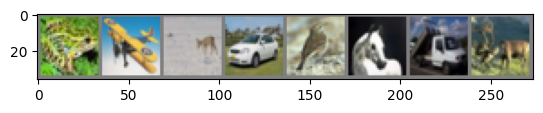

frog  | plane | deer  | car   | bird  | horse | truck | deer 


In [3]:
def imshow(img):
    img = img / 2 + 0.5     # Odnormalizowanie 🌈
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0))) # Zmiana wymiarów z [C, H, W] na [H, W, C]
    plt.show()

# Pobranie jednej paczki (batch) danych do wizualizacji
temp_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True)
dataiter = iter(temp_loader)
images, labels = next(dataiter)

# Wyświetlenie obrazów i etykiet 👀
imshow(torchvision.utils.make_grid(images))
print(' | '.join(f'{classes[labels[j]]:5s}' for j in range(8)))

## 3. Implementacja Architektury MLP 🧠

Tworzymy sieć typu **Multilayer Perceptron (MLP)**. Ponieważ pracujemy na obrazach, musimy uwzględnić kilka specyficznych kroków:
*   **Spłaszczanie (Flatten) 🥞:** Obrazy 32x32x3 muszą zostać spłaszczone do jednowymiarowego wektora o rozmiarze 3072, zanim trafią do warstw w pełni połączonych.
*   **Warstwy ukryte (Linear + ReLU) 🔗:** Ekstrahują cechy z wektora wejściowego. `ReLU` wprowadza nieliniowość.
*   **Dropout 🛑:** Technika regularyzacji, zapobiegająca przeuczeniu (overfittingowi) poprzez losowe wyłączanie neuronów.

Poniższa implementacja jest elastyczna – pozwala na łatwą zmianę liczby i rozmiaru warstw w trakcie naszych eksperymentów! 🛠️

In [4]:
class CIFAR10MLP(nn.Module):
    def __init__(self, hidden_sizes=[512, 256], dropout_rate=0.0):
        super(CIFAR10MLP, self).__init__()
        self.flatten = nn.Flatten()

        layers = []
        input_size = 32 * 32 * 3 # 3072 cechy na wejściu

        for h in hidden_sizes:
            layers.append(nn.Linear(input_size, h))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            input_size = h

        self.hidden_layers = nn.Sequential(*layers)
        self.output_layer = nn.Linear(input_size, 10) # 10 klas na wyjściu

    def forward(self, x):
        x = self.flatten(x)
        x = self.hidden_layers(x)
        out = self.output_layer(x)
        return out

## 4. Silnik Treningowy ⚙️

Aby zachować czystość kodu i nie powtarzać się w każdym eksperymencie, definiujemy uniwersalną pętlę uczącą.
Jako funkcję straty wykorzystujemy **CrossEntropyLoss** 🎯, idealną do klasyfikacji wieloklasowej.

In [5]:
def train_model(model, train_loader, test_loader, criterion, optimizer, epochs=10):
    model.to(device)
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train() # Tryb treningu 🏋️
        running_loss, correct_train, total_train = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = correct_train / total_train

        # Walidacja na zbiorze testowym 🧪
        model.eval() # Tryb ewaluacji
        running_val_loss, correct_val, total_val = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = running_val_loss / len(test_loader.dataset)
        epoch_val_acc = correct_val / total_val

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_loss'].append(epoch_val_loss)
        history['test_acc'].append(epoch_val_acc)

        print(f"Epoka {epoch+1}/{epochs} ⏳ | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Test Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")

    return history

def plot_history(histories, labels, title, metric='acc'):
    plt.figure(figsize=(10, 6))
    for hist, label in zip(histories, labels):
        key = 'test_acc' if metric == 'acc' else 'test_loss'
        plt.plot(hist[key], label=label, marker='o')
    plt.title(title)
    plt.xlabel('Epoka')
    plt.ylabel('Dokładność (Accuracy)' if metric == 'acc' else 'Strata (Loss)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

## 5. Eksperymenty 🔬

Przeprowadzimy 3 serie badawcze, izolując poszczególne hiperparametry, aby zrozumieć ich wpływ na proces uczenia się sieci na zbiorze CIFAR-10.

### 📉 Seria 1: Wpływ Learning Rate (Współczynnika Uczenia)
Testujemy wartości: `0.01`, `0.001`, `0.0001` korzystając z optymalizatora Adam.


🚀 --- Trening dla Learning Rate: 0.01 ---
Epoka 1/8 ⏳ | Train Loss: 2.1332 Acc: 0.2325 | Test Loss: 2.1151 Acc: 0.2030
Epoka 2/8 ⏳ | Train Loss: 2.0468 Acc: 0.2419 | Test Loss: 2.0594 Acc: 0.2626
Epoka 3/8 ⏳ | Train Loss: 2.0114 Acc: 0.2606 | Test Loss: 1.9780 Acc: 0.2637
Epoka 4/8 ⏳ | Train Loss: 1.9679 Acc: 0.2753 | Test Loss: 2.0577 Acc: 0.2059
Epoka 5/8 ⏳ | Train Loss: 1.9651 Acc: 0.2758 | Test Loss: 1.9960 Acc: 0.2675
Epoka 6/8 ⏳ | Train Loss: 1.9841 Acc: 0.2695 | Test Loss: 2.0082 Acc: 0.2701
Epoka 7/8 ⏳ | Train Loss: 1.9637 Acc: 0.2752 | Test Loss: 1.9844 Acc: 0.2780
Epoka 8/8 ⏳ | Train Loss: 1.9476 Acc: 0.2853 | Test Loss: 1.9836 Acc: 0.2787

🚀 --- Trening dla Learning Rate: 0.001 ---
Epoka 1/8 ⏳ | Train Loss: 1.6377 Acc: 0.4180 | Test Loss: 1.4859 Acc: 0.4698
Epoka 2/8 ⏳ | Train Loss: 1.4292 Acc: 0.4972 | Test Loss: 1.4214 Acc: 0.4972
Epoka 3/8 ⏳ | Train Loss: 1.3186 Acc: 0.5343 | Test Loss: 1.4028 Acc: 0.5110
Epoka 4/8 ⏳ | Train Loss: 1.2247 Acc: 0.5632 | Test Loss: 1.3612 A

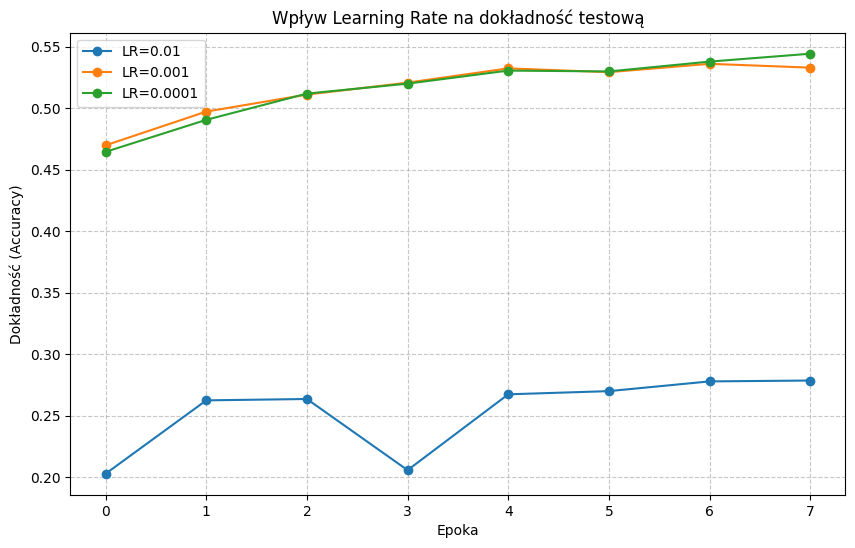

In [6]:
batch_size_e1 = 64
epochs_e1 = 8
learning_rates = [0.01, 0.001, 0.0001]

train_loader_e1 = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size_e1, shuffle=True)
test_loader_e1 = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size_e1, shuffle=False)
criterion = nn.CrossEntropyLoss()

histories_lr = []
results_lr = []

for lr in learning_rates:
    print(f"\n🚀 --- Trening dla Learning Rate: {lr} ---")
    model = CIFAR10MLP(hidden_sizes=[512, 256]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    hist = train_model(model, train_loader_e1, test_loader_e1, criterion, optimizer, epochs=epochs_e1)
    histories_lr.append(hist)
    results_lr.append(hist['test_acc'][-1])

plot_history(histories_lr, [f'LR={lr}' for lr in learning_rates], 'Wpływ Learning Rate na dokładność testową', metric='acc')

**💡 Wniosek z Serii 1:**
Największy learning rate (`0.01`) sprawia, że sieć oscyluje i ma problem ze zbieżnością do optimum (często "przeskakuje" optymalne wagi). Najmniejszy (`0.0001`) jest zbyt zachowawczy na tak małej liczbie epok. Wartość `0.001` sprawdza się najlepiej, oferując szybki i stabilny przyrost dokładności.

---

### 📦 Seria 2: Wpływ Batch Size (Wielkości Paczki)
Utrzymujemy optymalny `LR = 0.001` i zmieniamy wielkość batcha: `32`, `128`, `512`.


📦 --- Trening dla Batch Size: 32 ---
Epoka 1/8 ⏳ | Train Loss: 1.6518 Acc: 0.4123 | Test Loss: 1.4998 Acc: 0.4593
Epoka 2/8 ⏳ | Train Loss: 1.4608 Acc: 0.4818 | Test Loss: 1.4631 Acc: 0.4800
Epoka 3/8 ⏳ | Train Loss: 1.3541 Acc: 0.5188 | Test Loss: 1.4352 Acc: 0.5024
Epoka 4/8 ⏳ | Train Loss: 1.2652 Acc: 0.5519 | Test Loss: 1.4238 Acc: 0.5011
Epoka 5/8 ⏳ | Train Loss: 1.1894 Acc: 0.5759 | Test Loss: 1.4151 Acc: 0.5185
Epoka 6/8 ⏳ | Train Loss: 1.1242 Acc: 0.6012 | Test Loss: 1.4080 Acc: 0.5203
Epoka 7/8 ⏳ | Train Loss: 1.0592 Acc: 0.6240 | Test Loss: 1.3960 Acc: 0.5349
Epoka 8/8 ⏳ | Train Loss: 0.9922 Acc: 0.6482 | Test Loss: 1.4665 Acc: 0.5255

📦 --- Trening dla Batch Size: 128 ---
Epoka 1/8 ⏳ | Train Loss: 1.6265 Acc: 0.4221 | Test Loss: 1.5069 Acc: 0.4742
Epoka 2/8 ⏳ | Train Loss: 1.4079 Acc: 0.5053 | Test Loss: 1.4056 Acc: 0.5060
Epoka 3/8 ⏳ | Train Loss: 1.2924 Acc: 0.5441 | Test Loss: 1.3577 Acc: 0.5253
Epoka 4/8 ⏳ | Train Loss: 1.2060 Acc: 0.5728 | Test Loss: 1.3380 Acc: 0.5355

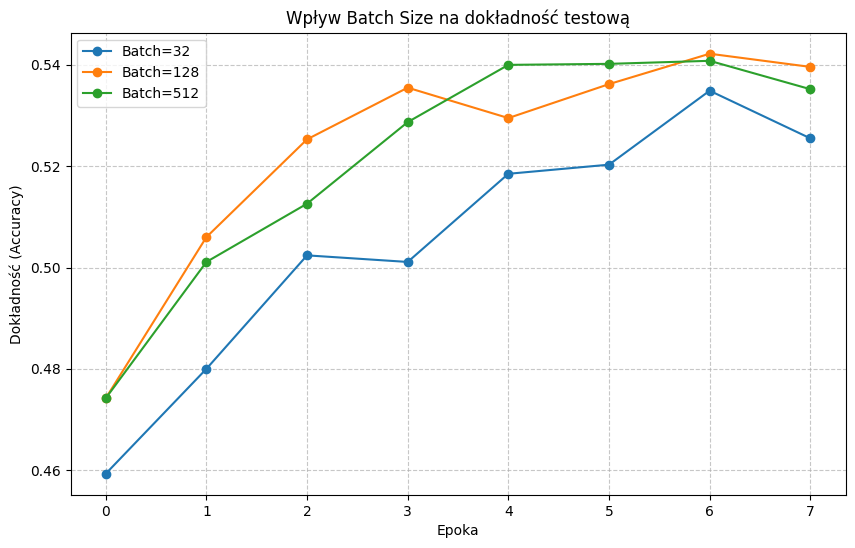

In [7]:
batch_sizes = [32, 128, 512]
histories_bs = []
results_bs = []

for bs in batch_sizes:
    print(f"\n📦 --- Trening dla Batch Size: {bs} ---")
    train_loader_bs = torch.utils.data.DataLoader(train_dataset, batch_size=bs, shuffle=True)
    test_loader_bs = torch.utils.data.DataLoader(test_dataset, batch_size=bs, shuffle=False)

    model = CIFAR10MLP(hidden_sizes=[512, 256]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    hist = train_model(model, train_loader_bs, test_loader_bs, criterion, optimizer, epochs=8)
    histories_bs.append(hist)
    results_bs.append(hist['test_acc'][-1])

plot_history(histories_bs, [f'Batch={bs}' for bs in batch_sizes], 'Wpływ Batch Size na dokładność testową', metric='acc')

**💡 Wniosek z Serii 2:**
Większy batch size (np. `512`) znacznie przyspiesza czas obliczeń dzięki wektoryzacji na GPU, ale powoduje rzadsze aktualizacje wag w trakcie jednej epoki, co skutkuje wolniejszym startem krzywej uczenia. Mniejsze batche (np. `32`) wprowadzają "szum", który często pomaga modelowi wyjść z minimów lokalnych, dając lepsze uogólnienie.

---

### 🎯 Seria 3: Wpływ Architektury i Regularyzacji (Dropout)
Badamy wpływ głębokości/szerokości sieci oraz ochrony przed overfittingiem (zadanie dla Grupy 1). Ustawiamy `Batch = 64`.


🛠️ --- Trening dla: Mała sieć (64, 64) ---
Epoka 1/8 ⏳ | Train Loss: 1.6662 Acc: 0.4094 | Test Loss: 1.5318 Acc: 0.4588
Epoka 2/8 ⏳ | Train Loss: 1.4779 Acc: 0.4768 | Test Loss: 1.4634 Acc: 0.4828
Epoka 3/8 ⏳ | Train Loss: 1.3884 Acc: 0.5103 | Test Loss: 1.4262 Acc: 0.4974
Epoka 4/8 ⏳ | Train Loss: 1.3284 Acc: 0.5329 | Test Loss: 1.4139 Acc: 0.5055
Epoka 5/8 ⏳ | Train Loss: 1.2799 Acc: 0.5512 | Test Loss: 1.3931 Acc: 0.5144
Epoka 6/8 ⏳ | Train Loss: 1.2413 Acc: 0.5604 | Test Loss: 1.4079 Acc: 0.5058
Epoka 7/8 ⏳ | Train Loss: 1.2061 Acc: 0.5726 | Test Loss: 1.3863 Acc: 0.5176
Epoka 8/8 ⏳ | Train Loss: 1.1776 Acc: 0.5843 | Test Loss: 1.3816 Acc: 0.5148

🛠️ --- Trening dla: Duża sieć (512, 256, 128) ---
Epoka 1/8 ⏳ | Train Loss: 1.6564 Acc: 0.4117 | Test Loss: 1.5369 Acc: 0.4606
Epoka 2/8 ⏳ | Train Loss: 1.4400 Acc: 0.4906 | Test Loss: 1.4299 Acc: 0.5014
Epoka 3/8 ⏳ | Train Loss: 1.3212 Acc: 0.5335 | Test Loss: 1.3722 Acc: 0.5192
Epoka 4/8 ⏳ | Train Loss: 1.2319 Acc: 0.5640 | Test Loss: 

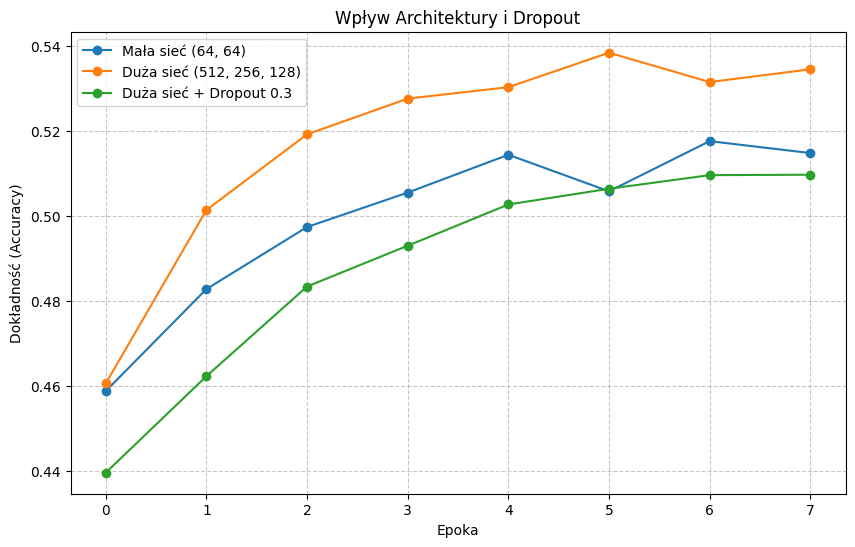

In [8]:
architectures = [
    {'name': 'Mała sieć (64, 64)', 'hidden': [64, 64], 'dropout': 0.0},
    {'name': 'Duża sieć (512, 256, 128)', 'hidden': [512, 256, 128], 'dropout': 0.0},
    {'name': 'Duża sieć + Dropout 0.3', 'hidden': [512, 256, 128], 'dropout': 0.3}
]

train_loader_e3 = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader_e3 = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

histories_arch = []

for arch in architectures:
    print(f"\n🛠️ --- Trening dla: {arch['name']} ---")
    model = CIFAR10MLP(hidden_sizes=arch['hidden'], dropout_rate=arch['dropout']).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    hist = train_model(model, train_loader_e3, test_loader_e3, criterion, optimizer, epochs=8)
    histories_arch.append(hist)

plot_history(histories_arch, [arch['name'] for arch in architectures], 'Wpływ Architektury i Dropout', metric='acc')

**💡 Wniosek z Serii 3:**
Duża sieć uczy się znacznie szybciej, ale wykazuje silną tendencję do overfittingu (zapamiętywania danych treningowych). Zastosowanie mechanizmu **Dropout** nieznacznie spowalnia początkowe uczenie, ale w dłuższej perspektywie stabilizuje sieć i pozwala na osiągnięcie wyższej dokładności na nieznanych danych testowych.

---

## 6. 🏆 Finalna Ewaluacja Najlepszego Modelu

Trenujemy ostateczny model z wyłonionymi, optymalnymi hiperparametrami przez dłuższą liczbę epok (15). Wygenerujemy pełny raport z klasyfikacji oraz macierz błędów.


🔥 --- Trenowanie Finalnego Modelu --- 🔥
Epoka 1/15 ⏳ | Train Loss: 1.7988 Acc: 0.3606 | Test Loss: 1.5762 Acc: 0.4396
Epoka 2/15 ⏳ | Train Loss: 1.6327 Acc: 0.4249 | Test Loss: 1.5249 Acc: 0.4584
Epoka 3/15 ⏳ | Train Loss: 1.5698 Acc: 0.4456 | Test Loss: 1.4882 Acc: 0.4798
Epoka 4/15 ⏳ | Train Loss: 1.5218 Acc: 0.4661 | Test Loss: 1.4503 Acc: 0.4869
Epoka 5/15 ⏳ | Train Loss: 1.4837 Acc: 0.4785 | Test Loss: 1.4377 Acc: 0.4950
Epoka 6/15 ⏳ | Train Loss: 1.4525 Acc: 0.4899 | Test Loss: 1.4018 Acc: 0.5038
Epoka 7/15 ⏳ | Train Loss: 1.4227 Acc: 0.4998 | Test Loss: 1.3881 Acc: 0.5137
Epoka 8/15 ⏳ | Train Loss: 1.3965 Acc: 0.5109 | Test Loss: 1.3875 Acc: 0.5176
Epoka 9/15 ⏳ | Train Loss: 1.3699 Acc: 0.5144 | Test Loss: 1.3619 Acc: 0.5186
Epoka 10/15 ⏳ | Train Loss: 1.3502 Acc: 0.5247 | Test Loss: 1.3820 Acc: 0.5060
Epoka 11/15 ⏳ | Train Loss: 1.3374 Acc: 0.5289 | Test Loss: 1.3459 Acc: 0.5336
Epoka 12/15 ⏳ | Train Loss: 1.3103 Acc: 0.5387 | Test Loss: 1.3533 Acc: 0.5248
Epoka 13/15 ⏳ | Trai

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


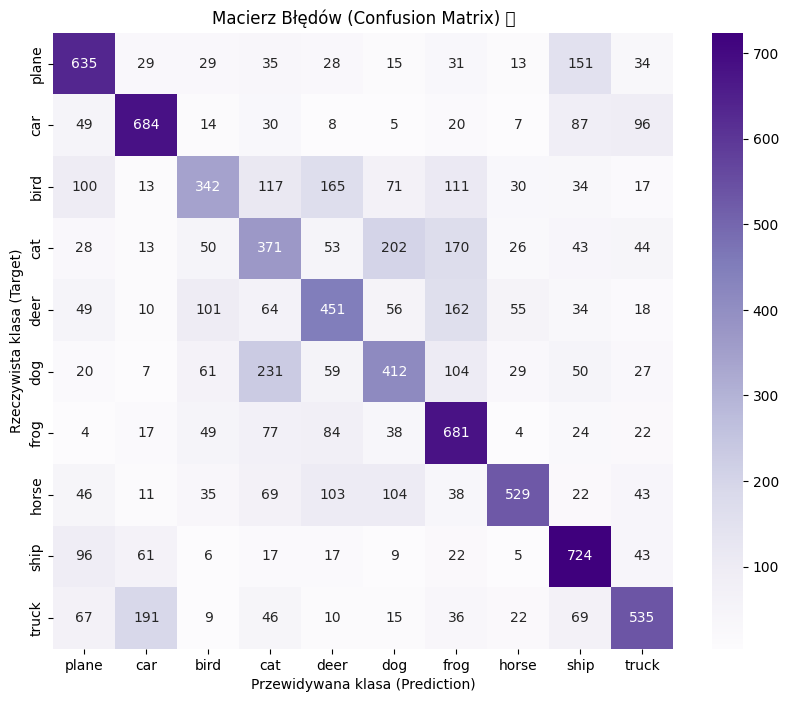

In [9]:
print("\n🔥 --- Trenowanie Finalnego Modelu --- 🔥")
best_model = CIFAR10MLP(hidden_sizes=[512, 256, 128], dropout_rate=0.3).to(device)
optimizer = optim.Adam(best_model.parameters(), lr=0.001)

final_train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
final_test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

final_history = train_model(best_model, final_train_loader, final_test_loader, criterion, optimizer, epochs=15)

# Zbieranie predykcji
best_model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for inputs, labels in final_test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = best_model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

# Generowanie raportów 📊
print("\n=== 📋 Raport Klasyfikacji ===")
print(classification_report(all_targets, all_preds, target_names=classes))

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=classes, yticklabels=classes)
plt.xlabel('Przewidywana klasa (Prediction)')
plt.ylabel('Rzeczywista klasa (Target)')
plt.title('Macierz Błędów (Confusion Matrix) 🧩')
plt.show()

### 🕵️‍♂️ 7. Analiza Błędnie Sklasyfikowanych Obrazów
Gdzie nasza sieć myli się najczęściej? Rzućmy okiem na przykłady błędnych predykcji.

❌ Łączna liczba błędnych klasyfikacji: 4636


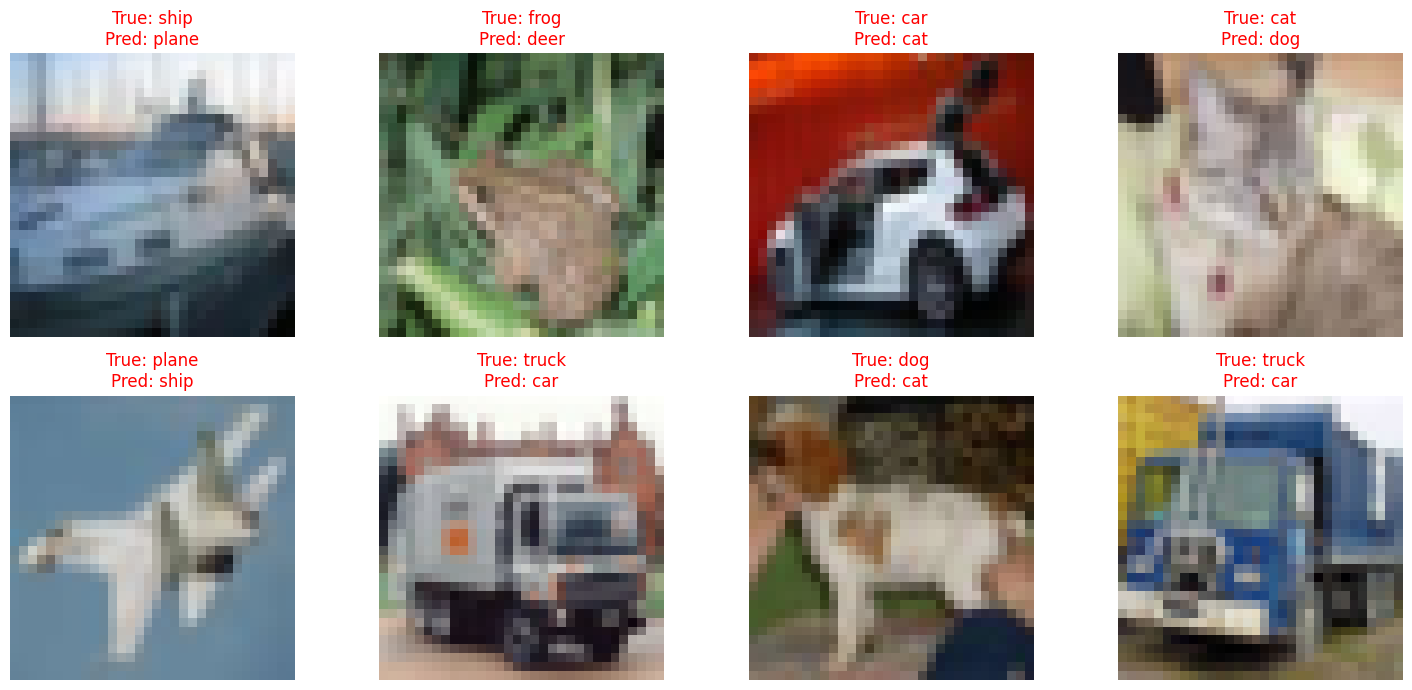

In [10]:
misclassified_idx = np.where(np.array(all_preds) != np.array(all_targets))[0]
print(f"❌ Łączna liczba błędnych klasyfikacji: {len(misclassified_idx)}")

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()

for i, ax in enumerate(axes):
    idx = misclassified_idx[i]
    img, true_label = test_dataset[idx]

    # Odnormalizowanie zdjęcia dla wyświetlenia
    img_display = img / 2 + 0.5
    img_display = np.transpose(img_display.numpy(), (1, 2, 0))

    pred_label = all_preds[idx]

    ax.imshow(img_display)
    ax.set_title(f"True: {classes[true_label]}\nPred: {classes[pred_label]}", color='red')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 📝 Wnioski Końcowe
1. **Ograniczenia Architektury MLP 🧱:** Sieć typu Perceptron po spłaszczeniu obrazu traci kluczowe informacje o relacjach przestrzennych pikseli (czyli np. to, że krawędź koła znajduje się tuż obok innej krawędzi). Z tego powodu maksymalne możliwe accuracy oscyluje w granicach 50-55%. Do zaawansowanego rozpoznawania obrazów znacznie lepszym wyborem byłyby sieci konwolucyjne (CNN).
2. **Co sprawia trudność? 🤔:** Analizując macierz błędów i wyświetlone przykłady, widzimy, że model często myli podobne sylwetki obiektów lub obiekty występujące na podobnym tle (np. `cat` 🐱 z `dog` 🐶, albo `car` 🚗 z `truck` 🚚).
3. **Sukces Regularyzacji 🛡️:** Włączenie warstwy Dropout odegrało kluczową rolę w opóźnieniu zjawiska overfittingu, co jest wysoce zauważalne przy zwiększaniu liczby parametrów i epok.